In [1]:
import pandas as pd

1) Clean the dataset

In [2]:
df = pd.read_csv('/content/cost_of_living_us.csv')
display(df.head())

,case_id,state,isMetro,areaname,county,family_member_count,housing_cost,food_cost,transportation_cost,healthcare_cost,other_necessities_cost,childcare_cost,taxes,total_cost,median_family_income
0,1,AL,True,"Montgomery, AL MSA",Autauga County,1p0c,8505.72876,3454.91712,10829.16876,5737.47984,4333.81344,0.0000,6392.94504,39254.0532,73010.414062
1,1,AL,True,"Montgomery, AL MSA",Autauga County,1p1c,12067.50240,5091.70788,11588.19288,8659.55640,6217.45896,6147.8298,7422.07836,57194.3256,73010.414062
2,1,AL,True,"Montgomery, AL MSA",Autauga County,1p2c,12067.50240,7460.20308,12361.77720,11581.63260,7075.65816,15824.6940,9769.56228,76141.0308,73010.414062
3,1,AL,True,"Montgomery, AL MSA",Autauga County,1p3c,15257.15040,9952.23924,13452.18600,14503.70760,9134.35620,18802.1892,13101.70320,94203.5328,73010.414062
4,1,AL,True,"Montgomery, AL MSA",Autauga County,1p4c,15257.15040,12182.21400,13744.59840,17425.78560,9942.36396,18802.1892,13469.21880,100823.5200,73010.414062


In [3]:
print(f"Shape of DataFrame before dropping nulls: {df.shape}")
df.dropna(inplace=True)
print(f"Shape of DataFrame after dropping nulls: {df.shape}")
display(df.head())

Shape of DataFrame before dropping nulls: (31430, 15)
Shape of DataFrame after dropping nulls: (31420, 15)


,case_id,state,isMetro,areaname,county,family_member_count,housing_cost,food_cost,transportation_cost,healthcare_cost,other_necessities_cost,childcare_cost,taxes,total_cost,median_family_income
0,1,AL,True,"Montgomery, AL MSA",Autauga County,1p0c,8505.72876,3454.91712,10829.16876,5737.47984,4333.81344,0.0000,6392.94504,39254.0532,73010.414062
1,1,AL,True,"Montgomery, AL MSA",Autauga County,1p1c,12067.50240,5091.70788,11588.19288,8659.55640,6217.45896,6147.8298,7422.07836,57194.3256,73010.414062
2,1,AL,True,"Montgomery, AL MSA",Autauga County,1p2c,12067.50240,7460.20308,12361.77720,11581.63260,7075.65816,15824.6940,9769.56228,76141.0308,73010.414062
3,1,AL,True,"Montgomery, AL MSA",Autauga County,1p3c,15257.15040,9952.23924,13452.18600,14503.70760,9134.35620,18802.1892,13101.70320,94203.5328,73010.414062
4,1,AL,True,"Montgomery, AL MSA",Autauga County,1p4c,15257.15040,12182.21400,13744.59840,17425.78560,9942.36396,18802.1892,13469.21880,100823.5200,73010.414062


In [5]:
summarized_df = df.groupby('state')[['total_cost', 'median_family_income']].mean().reset_index()
display(summarized_df)

,state,total_cost,median_family_income
0,AK,85234.557360,81242.831358
1,AL,68967.570020,58099.871502
2,AR,61491.891851,55025.567812
3,AZ,75985.939376,59661.879167
4,CA,93179.163060,82922.169248
5,CO,77595.782964,75158.805298
6,CT,90013.504620,103228.233398
7,DC,120289.636920,116607.390625
8,DE,81505.517560,81198.664062
9,FL,71521.722981,64294.176597


### Analysis of Costs, Income, and Family Size by State

Below are a series of bar charts visualizing the average values for transportation cost, healthcare cost, childcare cost, taxes, and median family income across different states. Additionally, we will analyze the average total family members per household by state.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import re

# --- Prepare Data for Numerical Columns ---

numerical_columns = [
    'transportation_cost',
    'healthcare_cost',
    'childcare_cost',
    'taxes',
    'median_family_income'
]

# Aggregate data: mean of specified numerical columns by state
state_avg_costs_income = df.groupby('state')[numerical_columns].mean().reset_index()

# --- Prepare Data for family_member_count ---

def parse_family_member_count(s):
    """Parses a string like '1p0c' to return the total number of family members."""
    match = re.match(r'(\d+)p(\d+)c', str(s))
    if match:
        parents = int(match.group(1))
        children = int(match.group(2))
        return parents + children
    return None # Handle cases that don't match the pattern

df['total_family_members'] = df['family_member_count'].apply(parse_family_member_count)

# Aggregate average total family members by state
state_avg_family_members = df.groupby('state')['total_family_members'].mean().reset_index()

# Set up matplotlib plotting style
sns.set_style("whitegrid")

#### Average Transportation Cost by State

This plot displays the average transportation cost for each state, allowing for a quick comparison of states with higher or lower transportation expenses.

/tmp/ipykernel_19527/2043190950.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='state', y='transportation_cost', data=state_avg_costs_income.sort_values(by='transportation_cost', ascending=False), palette='magma')


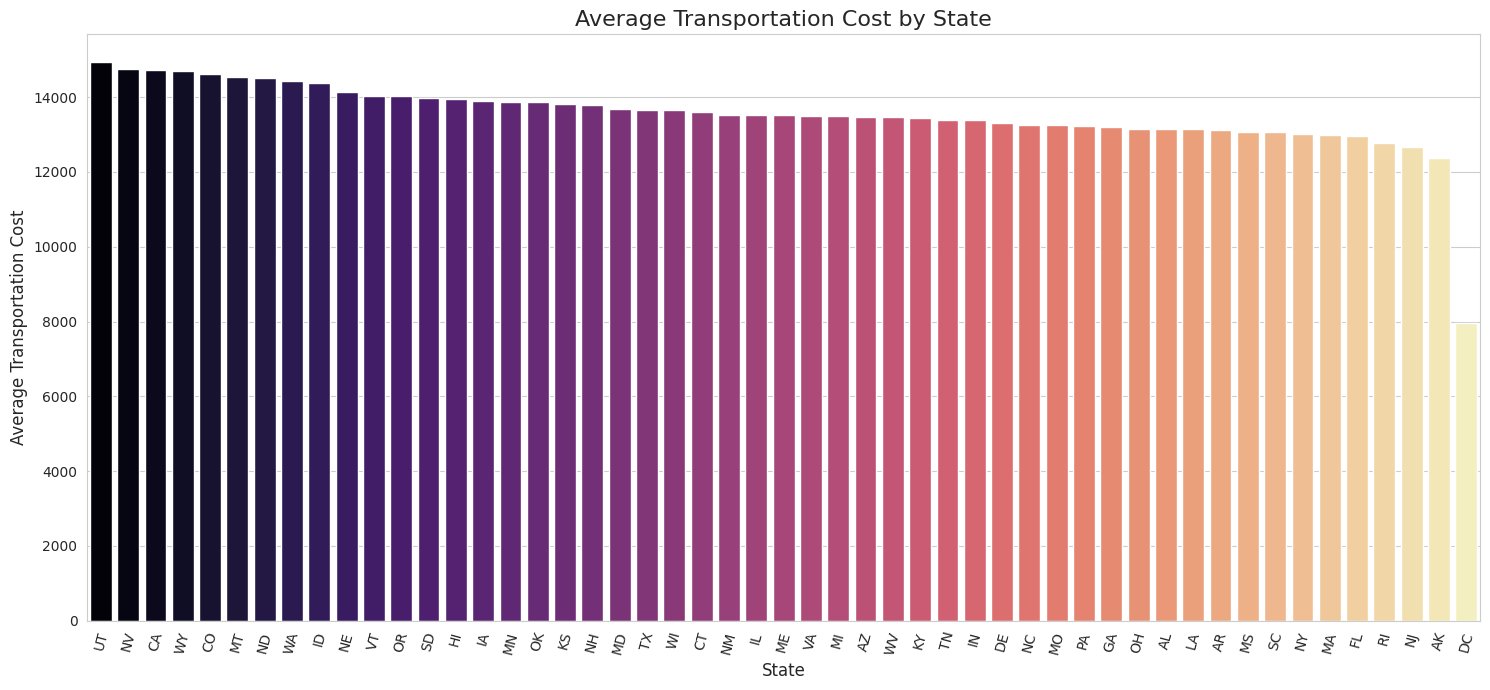

In [7]:
plt.figure(figsize=(15, 7))
sns.barplot(x='state', y='transportation_cost', data=state_avg_costs_income.sort_values(by='transportation_cost', ascending=False), palette='magma')
plt.title('Average Transportation Cost by State', fontsize=16)
plt.xlabel('State', fontsize=12)
plt.ylabel('Average Transportation Cost', fontsize=12)
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

#### 2) Average Healthcare Cost by State

This chart illustrates the average healthcare costs across different states, highlighting regional differences in healthcare expenses.

/tmp/ipykernel_19527/1036835865.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='state', y='healthcare_cost', data=state_avg_costs_income.sort_values(by='healthcare_cost', ascending=False), palette='crest')


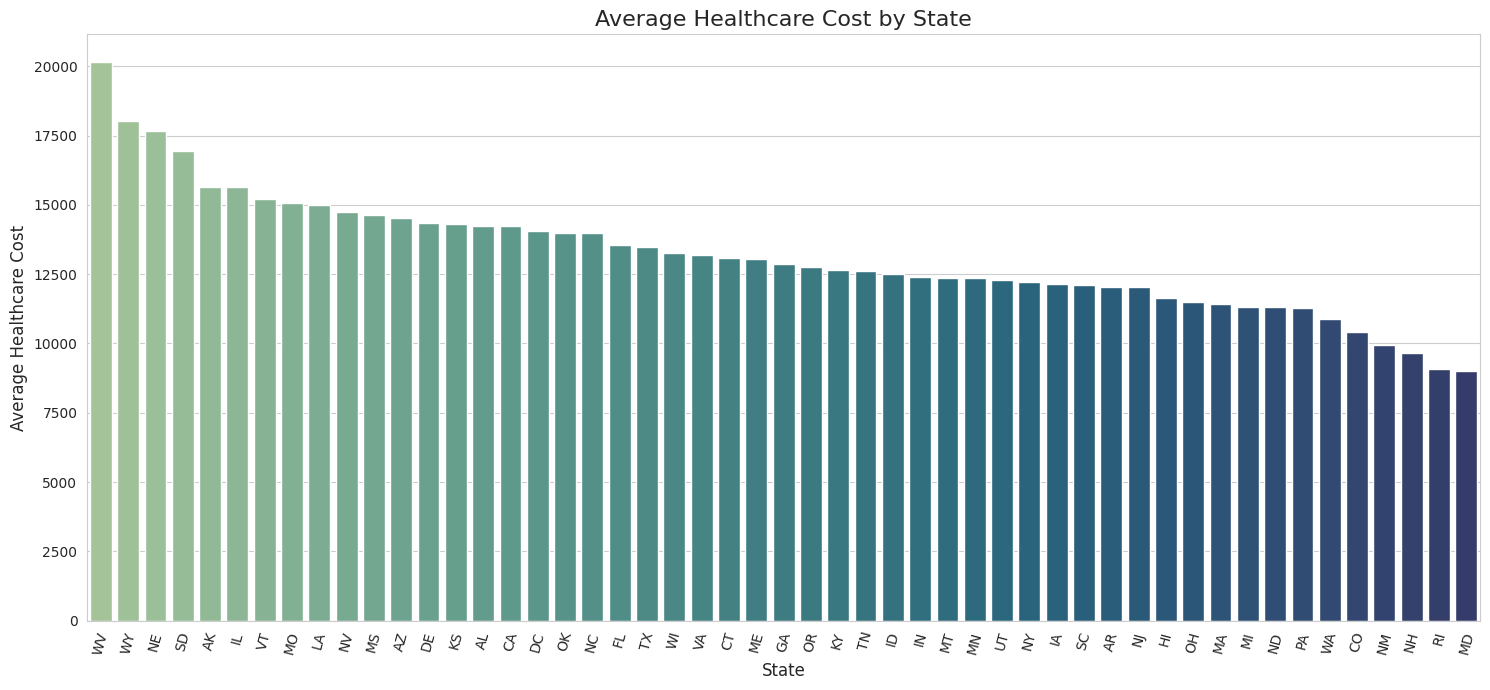

In [8]:
plt.figure(figsize=(15, 7))
sns.barplot(x='state', y='healthcare_cost', data=state_avg_costs_income.sort_values(by='healthcare_cost', ascending=False), palette='crest')
plt.title('Average Healthcare Cost by State', fontsize=16)
plt.xlabel('State', fontsize=12)
plt.ylabel('Average Healthcare Cost', fontsize=12)
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

#### Average Childcare Cost by State

This graph shows the average childcare costs in each state, providing insight into the varying expenses for childcare across the US.

/tmp/ipykernel_19527/956568519.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='state', y='childcare_cost', data=state_avg_costs_income.sort_values(by='childcare_cost', ascending=False), palette='viridis')


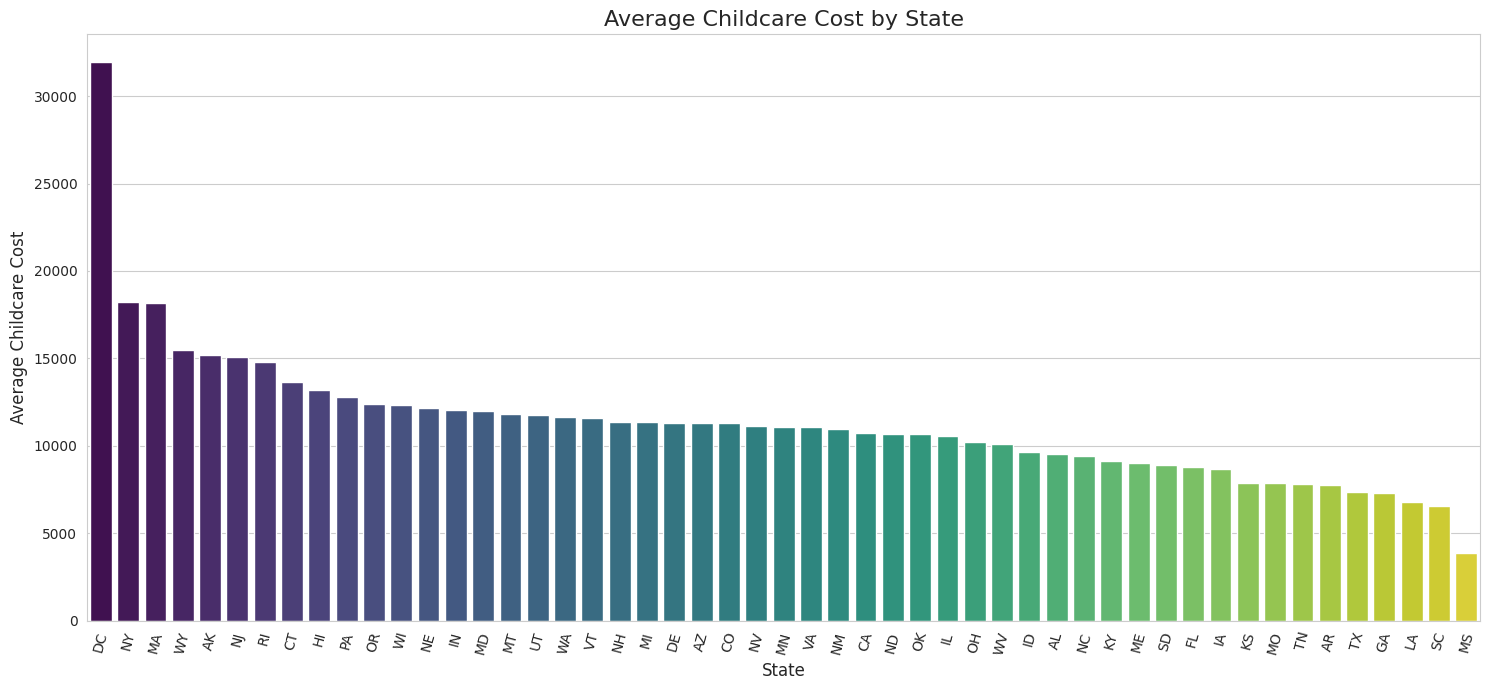

In [9]:
plt.figure(figsize=(15, 7))
sns.barplot(x='state', y='childcare_cost', data=state_avg_costs_income.sort_values(by='childcare_cost', ascending=False), palette='viridis')
plt.title('Average Childcare Cost by State', fontsize=16)
plt.xlabel('State', fontsize=12)
plt.ylabel('Average Childcare Cost', fontsize=12)
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

#### Average Taxes by State

This bar chart represents the average tax burden per state, useful for understanding the tax landscape across different regions.

/tmp/ipykernel_19527/3401471136.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='state', y='taxes', data=state_avg_costs_income.sort_values(by='taxes', ascending=False), palette='mako')


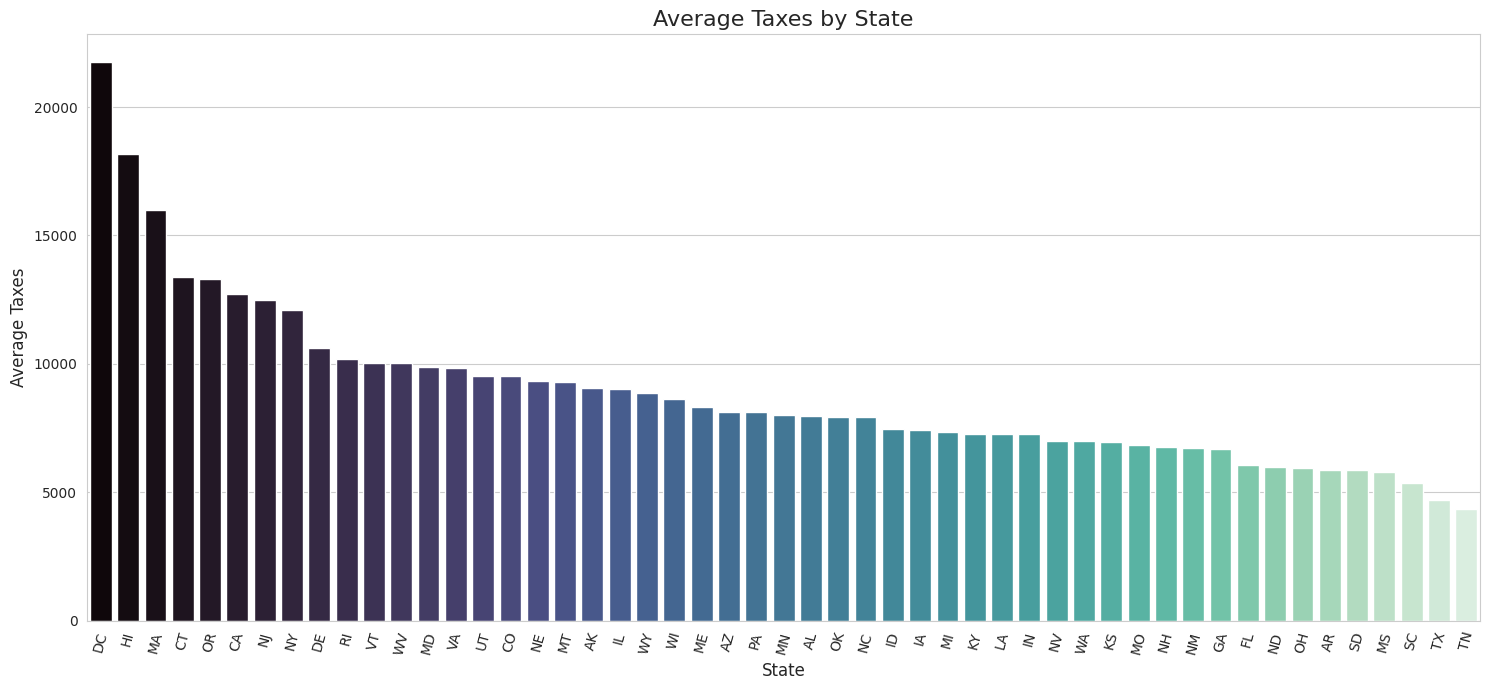

In [10]:
plt.figure(figsize=(15, 7))
sns.barplot(x='state', y='taxes', data=state_avg_costs_income.sort_values(by='taxes', ascending=False), palette='mako')
plt.title('Average Taxes by State', fontsize=16)
plt.xlabel('State', fontsize=12)
plt.ylabel('Average Taxes', fontsize=12)
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

#### Average Median Family Income by State

This plot visualizes the average median family income for each state, offering a perspective on economic prosperity variations across states.

/tmp/ipykernel_19527/833548052.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='state', y='median_family_income', data=state_avg_costs_income.sort_values(by='median_family_income', ascending=False), palette='rocket')


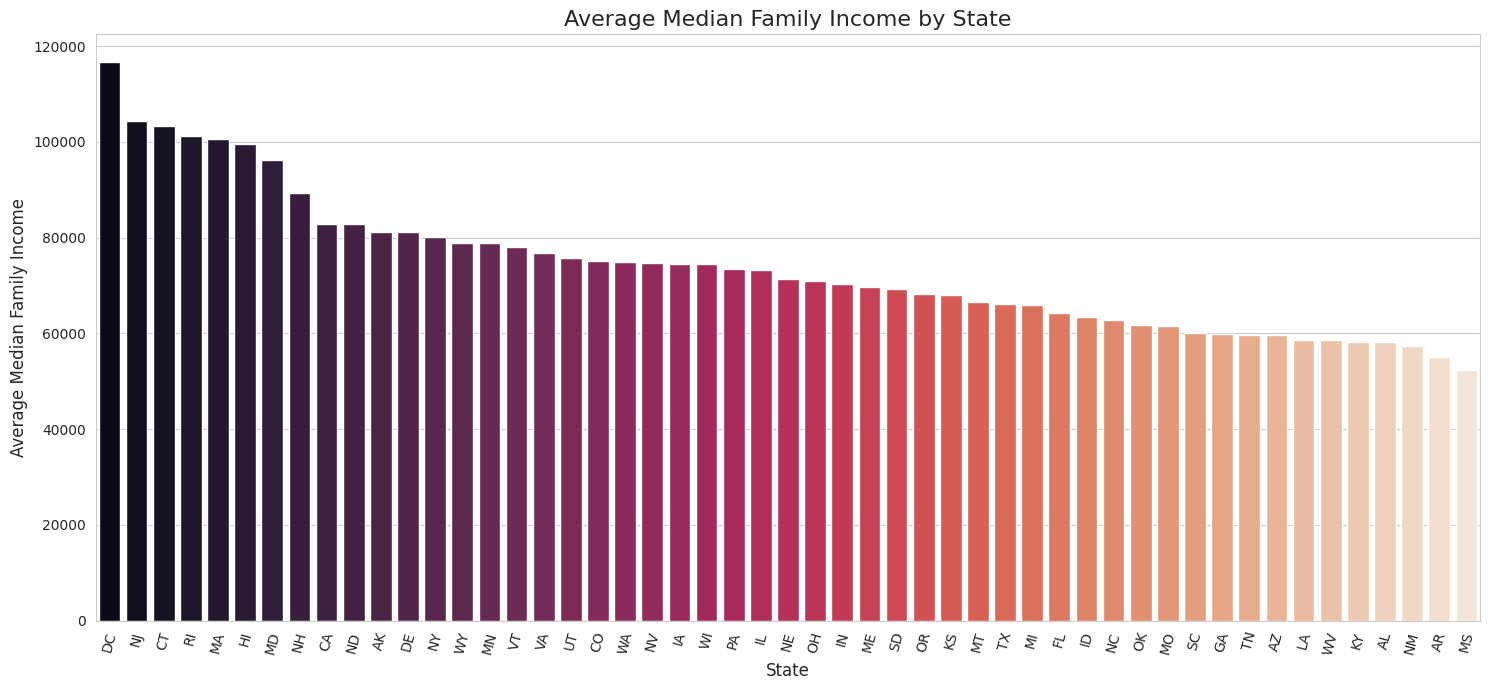

In [11]:
plt.figure(figsize=(15, 7))
sns.barplot(x='state', y='median_family_income', data=state_avg_costs_income.sort_values(by='median_family_income', ascending=False), palette='rocket')
plt.title('Average Median Family Income by State', fontsize=16)
plt.xlabel('State', fontsize=12)
plt.ylabel('Average Median Family Income', fontsize=12)
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

#### Average Total Family Members per Household by State

This chart shows the average number of family members per household for each state, providing insights into typical household sizes across the US.

/tmp/ipykernel_19527/4163493301.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='state', y='total_family_members', data=state_avg_family_members.sort_values(by='total_family_members', ascending=False), palette='flare')


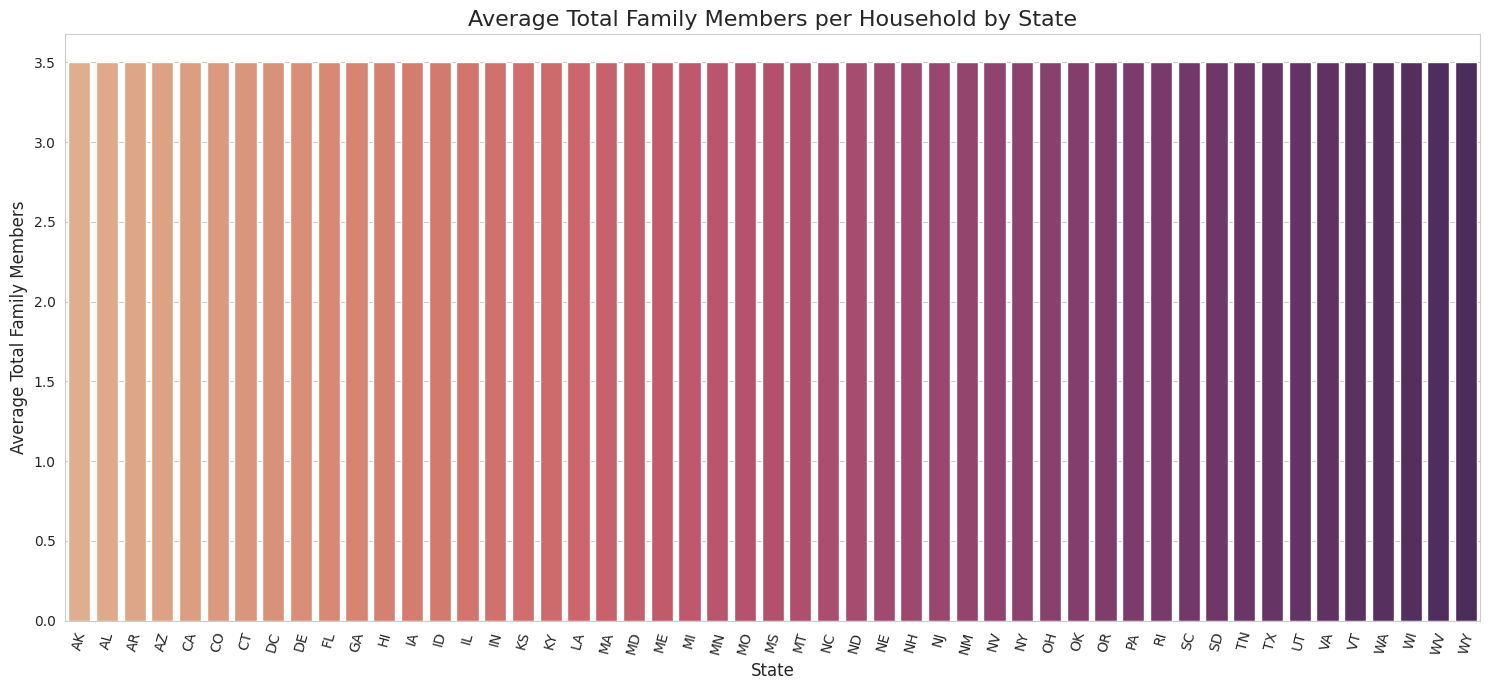

In [12]:
plt.figure(figsize=(15, 7))
sns.barplot(x='state', y='total_family_members', data=state_avg_family_members.sort_values(by='total_family_members', ascending=False), palette='flare')
plt.title('Average Total Family Members per Household by State', fontsize=16)
plt.xlabel('State', fontsize=12)
plt.ylabel('Average Total Family Members', fontsize=12)
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

#### 3) Summarized Data by State with Color-Coded Values

This table displays the average total cost and median family income for each state. The color gradient helps to quickly identify states with higher (darker color) or lower (lighter color) values for each metric.

In [13]:
styled_summarized_df = summarized_df.style.background_gradient(subset=['total_cost', 'median_family_income'], cmap='viridis')
display(styled_summarized_df)

,state,total_cost,median_family_income
0,AK,85234.557360,81242.831358
1,AL,68967.570020,58099.871502
2,AR,61491.891851,55025.567812
3,AZ,75985.939376,59661.879167
4,CA,93179.163060,82922.169248
5,CO,77595.782964,75158.805298
6,CT,90013.504620,103228.233398
7,DC,120289.636920,116607.390625
8,DE,81505.517560,81198.664062
9,FL,71521.722981,64294.176597


#### Color Key for Table Gradients

This color bar illustrates the 'viridis' colormap used in the table. Darker shades correspond to higher values, and lighter shades to lower values for both 'total_cost' and 'median_family_income'.

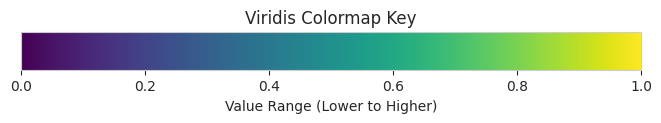

In [14]:
import numpy as np
import matplotlib.colors as mcolors

# Create a figure and an axis
fig, ax = plt.subplots(figsize=(8, 1))
fig.subplots_adjust(bottom=0.5)

# Create a colormap instance
cmap = plt.get_cmap('viridis')
norm = mcolors.Normalize(vmin=0, vmax=1)

# Create a colorbar
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm),
                     cax=ax, orientation='horizontal')

cbar.set_label('Value Range (Lower to Higher)')
plt.title('Viridis Colormap Key')
plt.show()

#### 4) Analyzing Relationships Between Cost Components and Income by State

In [17]:
import plotly.express as px

# Calculate average housing_cost by state
state_avg_housing_cost = df.groupby('state')['housing_cost'].mean().reset_index()

# Merge summarized_df (for total_cost) into state_avg_costs_income
combined_state_data = pd.merge(state_avg_costs_income, summarized_df[['state', 'total_cost']], on='state', how='left')

# Merge state_avg_housing_cost into combined_state_data
combined_state_data = pd.merge(combined_state_data, state_avg_housing_cost, on='state', how='left')

display(combined_state_data.head())


,state,transportation_cost,healthcare_cost,childcare_cost,taxes,median_family_income,total_cost,housing_cost
0,AK,12361.720750,15641.815574,15194.391719,9047.294052,81242.831358,85234.557360,15520.427586
1,AL,13141.568890,14236.294295,9552.574830,7975.351473,58099.871502,68967.570020,9181.392518
2,AR,13131.927386,12038.511863,7732.104276,5872.369266,55025.567812,61491.891851,8886.487749
3,AZ,13479.581414,14532.482911,11314.893078,8131.322522,59661.879167,75985.939376,12793.910734
4,CA,14740.170922,14221.493600,10761.334636,12713.440853,82922.169248,93179.163060,20232.487360


##### 5) Total Cost vs. Transportation Cost by State

In [16]:
import plotly.express as px

fig = px.choropleth(
    state_avg_costs_income,
    locations='state',
    locationmode='USA-states',
    color='transportation_cost',
    scope='usa',
    color_continuous_scale='Plasma',
    range_color=[10000, 18000],  # Adjusted range for a smaller key
    title='Average Transportation Cost by State',
    hover_name='state',
    hover_data={'transportation_cost': True}
)
fig.update_layout(
    geo_scope='usa',
    margin={"r":0,"t":50,"l":0,"b":0}
)
fig.show()

6) Plots for:
a.  total_cost vs. transportation_cost
b. childcare_cost vs. taxes
c. median_family_income vs. taxes
d. housing cost vs. taxes

In [18]:
fig_a = px.scatter(combined_state_data,
                   x='transportation_cost',
                   y='total_cost',
                   color='state',
                   hover_name='state',
                   title='Total Cost vs. Transportation Cost by State',
                   labels={'transportation_cost': 'Average Transportation Cost', 'total_cost': 'Average Total Cost'})
fig_a.update_layout(showlegend=False) # Hide legend as hover provides state info
fig_a.show()


##### b. Childcare Cost vs. Taxes by State

In [19]:
fig_b = px.scatter(combined_state_data,
                   x='taxes',
                   y='childcare_cost',
                   color='state',
                   hover_name='state',
                   title='Childcare Cost vs. Taxes by State',
                   labels={'taxes': 'Average Taxes', 'childcare_cost': 'Average Childcare Cost'})
fig_b.update_layout(showlegend=False)
fig_b.show()


##### c. Median Family Income vs. Taxes by State

In [20]:
fig_c = px.scatter(combined_state_data,
                   x='taxes',
                   y='median_family_income',
                   color='state',
                   hover_name='state',
                   title='Median Family Income vs. Taxes by State',
                   labels={'taxes': 'Average Taxes', 'median_family_income': 'Average Median Family Income'})
fig_c.update_layout(showlegend=False)
fig_c.show()


##### d. Housing Cost vs. Taxes by State

In [21]:
fig_d = px.scatter(combined_state_data,
                   x='taxes',
                   y='housing_cost',
                   color='state',
                   hover_name='state',
                   title='Housing Cost vs. Taxes by State',
                   labels={'taxes': 'Average Taxes', 'housing_cost': 'Average Housing Cost'})
fig_d.update_layout(showlegend=False)
fig_d.show()


#### Trends and Patterns Observed in the Scatter Plots:

**a. Total Cost vs. Transportation Cost by State:**
*   **Trend:** There appears to be a positive correlation between total cost and transportation cost. States with higher overall living costs tend to also have higher transportation costs.
*   **Patterns:** States like Alaska and Hawaii often stand out with very high total and transportation costs, likely due to geographical isolation and logistical challenges. Other states show a more clustered relationship, generally moving together.

**b. Childcare Cost vs. Taxes by State:**
*   **Trend:** A positive correlation is noticeable, indicating that states with higher average taxes also tend to have higher childcare costs. This could be influenced by various factors, including state-specific regulations, labor costs, and funding for public services that indirectly affect childcare expenses.
*   **Patterns:** Some states might deviate significantly from the general trend, potentially indicating unique local policies or economic conditions affecting either taxes or childcare costs independently.

**c. Median Family Income vs. Taxes by State:**
*   **Trend:** There is generally a positive correlation between median family income and taxes. Higher income states often collect more in taxes, which is expected as tax systems are often progressive or tied to economic activity.
*   **Patterns:** States with very high median family incomes often also have some of the highest tax burdens. However, the relationship isn't perfectly linear, as different states have varied tax structures (e.g., income tax, sales tax, property tax), which can affect this correlation.

**d. Housing Cost vs. Taxes by State:**
*   **Trend:** A positive correlation exists between housing costs and taxes. States with more expensive housing markets tend to have higher average taxes. This is often driven by property taxes, which are a significant component of local government revenue and are directly tied to property values.
*   **Patterns:** Highly populated and desirable coastal states often exhibit both high housing costs and high taxes, contributing to a higher cost of living. There might be outliers where housing costs are high but taxes are relatively lower, or vice-versa, depending on specific state policies and market dynamics.

#### 7) Top 12 Most Expensive Counties for Childcare Cost

#### Choropleth Map of Average Transportation Cost by State

This choropleth map visually represents the average transportation cost across different states, allowing for an immediate understanding of geographical variations. Darker shades indicate higher costs, while lighter shades represent lower costs.

#### Comparison with Bar Chart for Transportation Cost

Comparing this choropleth map with the bar chart for average transportation cost by state (generated in cell `7ef93b59`):

*   **Visual Representation:** The bar chart provides precise values for each state, making it easy to compare exact costs. The choropleth map, on the other hand, offers an immediate geographical overview, highlighting regions with high or low transportation costs at a glance.

*   **Patterns:** Both visualizations should reveal similar patterns. For example, states that were at the top of the bar chart (e.g., Alaska, Hawaii) should appear in darker shades on the choropleth map, indicating higher transportation costs. Similarly, states with lower costs should be lighter.

*   **Strengths:** The bar chart is excellent for ranking states by cost. The choropleth map is superior for understanding spatial distributions and identifying clusters of high or low costs.

In essence, both visualizations convey the same information about average transportation costs, but in different formats, each offering unique insights into the data.

In [22]:
county_avg_childcare_cost = df.groupby('county')['childcare_cost'].mean().reset_index()
top_12_childcare_counties = county_avg_childcare_cost.sort_values(by='childcare_cost', ascending=False).head(12)
display(top_12_childcare_counties)

,county,childcare_cost
493,District of Columbia,31940.492400
1187,New York County,29620.246800
1379,Queens County,28050.334320
1439,Rockland County,27260.377200
1796,Westchester County,26661.030720
1617,Suffolk County,25288.633680
206,Bronx County,24340.542960
1203,Norfolk County,23606.173680
519,Dutchess County,22844.859600
1714,Ulster County,21947.080944


#### 8) Top 12 Most Expensive Counties for Taxes

In [23]:
county_avg_taxes = df.groupby('county')['taxes'].mean().reset_index()
top_12_tax_counties = county_avg_taxes.sort_values(by='taxes', ascending=False).head(12)
display(top_12_tax_counties)

,county,taxes
1480,San Mateo County,34738.964880
1043,Marin County,31637.529360
1475,San Francisco County,27174.135960
1187,New York County,26517.054360
1492,Santa Clara County,24651.857760
1439,Rockland County,23463.096600
1379,Queens County,22807.598208
1203,Norfolk County,22347.509448
1796,Westchester County,22292.750676
1617,Suffolk County,22256.451666


#### 9) Correlation Matrix of Cost Components and Income by State

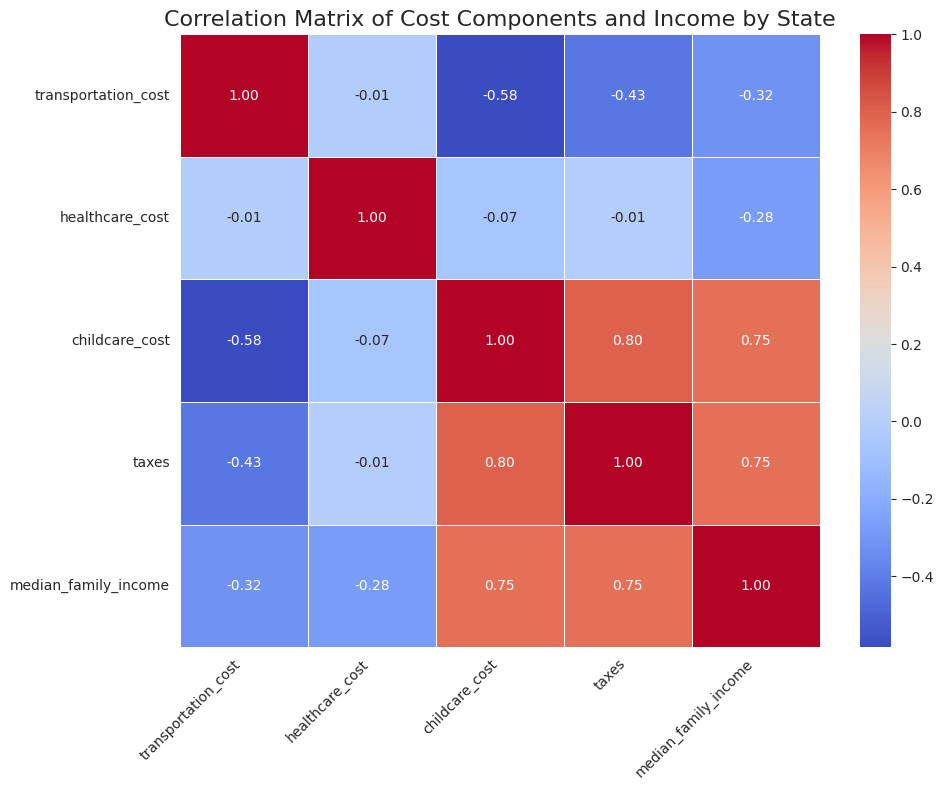

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for the numerical columns in state_avg_costs_income
correlation_matrix = state_avg_costs_income[numerical_columns].corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix,
            annot=True, # Show the correlation values on the heatmap
            cmap='coolwarm', # Choose a diverging colormap
            fmt=".2f", # Format annotation to two decimal places
            linewidths=.5) # Add lines between cells

plt.title('Correlation Matrix of Cost Components and Income by State', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### 10) Regression Analysis: Total Cost vs. Taxes by State

This plot shows the linear relationship between average taxes and average total cost by state. The red line represents the regression line, indicating the general trend. The shaded area around the regression line is the 95% confidence interval, showing the uncertainty of the regression estimate.

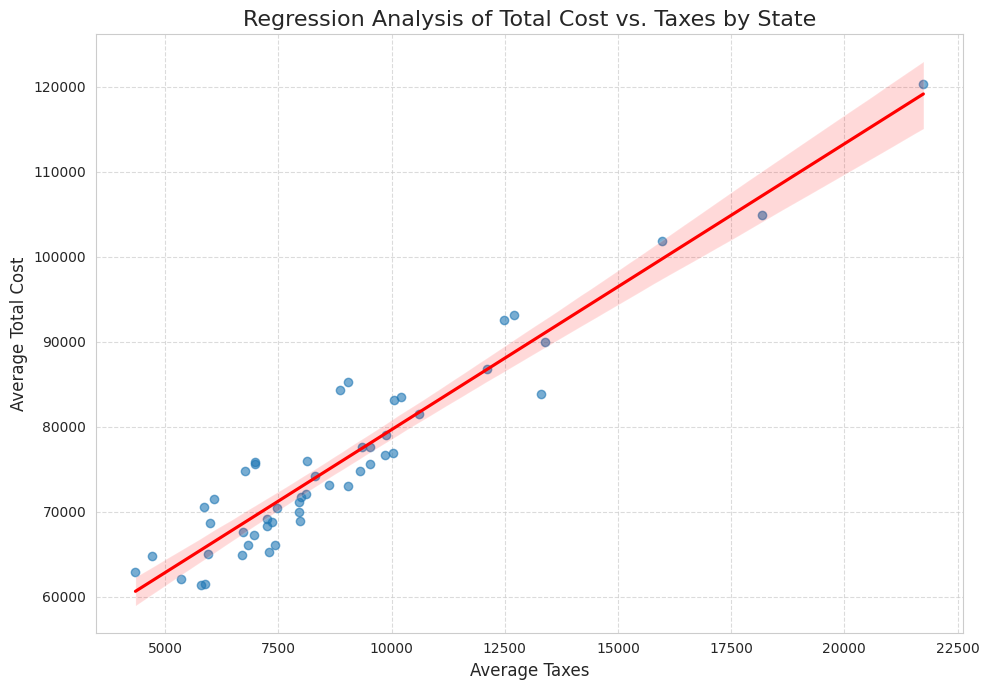

In [25]:
plt.figure(figsize=(10, 7))
sns.regplot(x='taxes', y='total_cost', data=combined_state_data, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Regression Analysis of Total Cost vs. Taxes by State', fontsize=16)
plt.xlabel('Average Taxes', fontsize=12)
plt.ylabel('Average Total Cost', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Interpretation of the Correlation Matrix:

*   **Positive Correlation (closer to 1):** Indicates that as one variable increases, the other tends to increase as well. For example, a high positive correlation between `childcare_cost` and `taxes` would suggest that states with higher childcare costs also tend to have higher taxes.
*   **Negative Correlation (closer to -1):** Indicates that as one variable increases, the other tends to decrease. For example, a negative correlation between `median_family_income` and `childcare_cost` would suggest that higher income states tend to have lower childcare costs (though this is not commonly the case for these variables).
*   **No Correlation (closer to 0):** Indicates a weak or no linear relationship between the variables.

In [26]:
state_avg_food_cost = df.groupby('state')['food_cost'].mean().reset_index()
combined_state_data = pd.merge(combined_state_data, state_avg_food_cost, on='state', how='left')
display(combined_state_data.head())

,state,transportation_cost,healthcare_cost,childcare_cost,taxes,median_family_income,total_cost,housing_cost,food_cost
0,AK,12361.720750,15641.815574,15194.391719,9047.294052,81242.831358,85234.557360,15520.427586,8694.782041
1,AL,13141.568890,14236.294295,9552.574830,7975.351473,58099.871502,68967.570020,9181.392518,8480.711293
2,AR,13131.927386,12038.511863,7732.104276,5872.369266,55025.567812,61491.891851,8886.487749,7788.489356
3,AZ,13479.581414,14532.482911,11314.893078,8131.322522,59661.879167,75985.939376,12793.910734,8146.288516
4,CA,14740.170922,14221.493600,10761.334636,12713.440853,82922.169248,93179.163060,20232.487360,9673.952906


#### 11) Outlier Detection for Food Cost using IQR Method

In [28]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for 'food_cost'
Q1 = df['food_cost'].quantile(0.25)
Q3 = df['food_cost'].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Define the outlier fences
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25th percentile): {Q1:.2f}")
print(f"Q3 (75th percentile): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound for Outliers: {lower_bound:.2f}")
print(f"Upper Bound for Outliers: {upper_bound:.2f}")

# Identify outliers
outliers = df[(df['food_cost'] < lower_bound) | (df['food_cost'] > upper_bound)]

display(f"Number of outliers found: {len(outliers)}")
display("First 10 rows of food_cost outliers:")
display(outliers.head(10))

Q1 (25th percentile): 5801.42
Q3 (75th percentile): 10703.62
IQR: 4902.20
Lower Bound for Outliers: -1551.88
Upper Bound for Outliers: 18056.92


'Number of outliers found: 66'

'First 10 rows of food_cost outliers:'

,case_id,state,isMetro,areaname,county,family_member_count,housing_cost,food_cost,transportation_cost,healthcare_cost,other_necessities_cost,childcare_cost,taxes,total_cost,median_family_income,total_family_members
684,69,AK,False,"Aleutians West Census Area, AK",Aleutians West Census Area,1p4c,23808.0000,19280.3016,3175.38504,19130.8248,15612.5916,25498.0776,15600.3912,122105.568,98061.890625,5
688,69,AK,False,"Aleutians West Census Area, AK",Aleutians West Census Area,2p3c,23808.0000,19298.8932,4032.33984,22309.7172,15619.3284,25498.0776,14244.5928,124810.944,98061.890625,5
689,69,AK,False,"Aleutians West Census Area, AK",Aleutians West Census Area,2p4c,23808.0000,23698.7700,3692.81256,25500.1020,17213.5764,25498.0776,15038.9292,134450.268,98061.890625,6
1889,189,CA,False,"Amador County, CA",Amador County,2p4c,19728.0000,18814.6812,18953.74080,22294.1688,13965.5328,13684.1556,14504.3124,121944.600,79965.101562,6
1909,191,CA,False,"Calaveras County, CA",Calaveras County,2p4c,18216.0000,19889.8080,18398.39400,25404.4044,13807.2360,13294.8384,15270.8124,124281.492,83174.960938,6
1949,195,CA,True,"Sacramento--Roseville--Arden-Arcade, CA HUD Me...",El Dorado County,2p4c,25085.8560,20024.1984,18052.33320,21923.7300,16345.1532,15567.8016,19124.5080,136123.584,105534.101562,6
2069,207,CA,True,"San Francisco, CA HUD Metro FMR Area",Marin County,2p4c,55151.5248,20651.3568,19816.48200,22450.0776,27466.3740,23739.2388,42864.5484,212139.612,157777.984375,6
2139,214,CA,True,"Napa, CA MSA",Napa County,2p4c,33912.0000,19621.0296,17754.09840,22450.0776,19397.1288,17479.5840,25547.9388,156161.856,104746.523438,6
2149,215,CA,False,"Nevada County, CA",Nevada County,2p4c,22932.0000,21502.4952,18272.43480,25404.4044,16100.3700,14297.5536,19845.2412,138354.504,87976.398438,6
2209,221,CA,True,"San Benito County, CA HUD Metro FMR Area",San Benito County,2p4c,28752.0000,19710.6228,18000.12360,31637.2320,17559.9180,16563.0624,26295.4536,158518.416,97108.992188,6


#### Interpretation of Food Cost Outliers

The output above identifies data points in the `food_cost` column that are considered outliers based on the IQR method. Outliers are values that fall significantly below the `lower_bound` or significantly above the `upper_bound`.

*   **Lower Bound**: Any `food_cost` value below this amount is considered a lower outlier.
*   **Upper Bound**: Any `food_cost` value above this amount is considered an upper outlier.

The `display` statements show the total count of identified outliers and the first 10 rows of the DataFrame corresponding to these outliers. Analyzing these outliers can reveal states or counties with exceptionally high or low food costs, which might warrant further investigation to understand the underlying economic or geographical factors.

#### 12) Bubble Plot: Food Cost vs. Taxes, Sized by Childcare Cost and Colored by Metropolitan Status

This bubble plot visualizes the intricate relationships between several cost components. Each bubble represents a data point (likely a county or state, depending on the granularity of `df` which was used for `isMetro`).

*   **X-axis (Taxes)**: Shows the average tax amount.
*   **Y-axis (Food Cost)**: Shows the average food cost.
*   **Bubble Size (Childcare Cost)**: The size of each bubble is proportional to the average childcare cost in that region. Larger bubbles indicate higher childcare costs.
*   **Bubble Color (isMetro)**: The color of the bubble differentiates between metropolitan (`True`) and non-metropolitan (`False`) areas, allowing for an immediate visual distinction between these two categories.

This plot can help identify patterns such as whether metropolitan areas tend to have higher taxes, food costs, and childcare costs, and how these factors interrelate across different regions.

In [29]:
fig = px.scatter(df, # Use the original df to include 'isMetro' for individual points
                 x='taxes',
                 y='food_cost',
                 size='childcare_cost',
                 color='isMetro',
                 hover_name='county',
                 title='Food Cost vs. Taxes (Sized by Childcare Cost, Colored by isMetro)',
                 labels={'taxes': 'Taxes', 'food_cost': 'Food Cost', 'childcare_cost': 'Childcare Cost', 'isMetro': 'Metropolitan Area'},
                 log_x=False, # Set to True if tax distribution is highly skewed
                 size_max=60) # Adjust maximum bubble size for better visualization

fig.update_layout(showlegend=True)
fig.show()

13) Bubble Chart for Housing vs. Taxes

#### Bubble Plot: Housing Cost vs. Taxes, Sized by Transportation Cost and Colored by State

This bubble plot explores the relationship between housing costs and taxes, incorporating transportation cost as bubble size and differentiating by state with color.

*   **X-axis (Taxes)**: Shows the average tax amount.
*   **Y-axis (Housing Cost)**: Shows the average housing cost.
*   **Bubble Size (Transportation Cost)**: The size of each bubble is proportional to the average transportation cost in that state. Larger bubbles indicate higher transportation costs.
*   **Bubble Color (State)**: The color of the bubble represents the state, allowing for easy identification and comparison of individual states' positions relative to these metrics.

This plot can help identify states with particular combinations of housing costs, taxes, and transportation expenses, revealing potential correlations or unique regional characteristics.

In [30]:
fig = px.scatter(combined_state_data,
                 x='taxes',
                 y='housing_cost',
                 size='transportation_cost',
                 color='state',
                 hover_name='state',
                 title='Housing Cost vs. Taxes (Sized by Transportation Cost, Colored by State)',
                 labels={'taxes': 'Average Taxes', 'housing_cost': 'Average Housing Cost', 'transportation_cost': 'Average Transportation Cost'},
                 size_max=60) # Adjust maximum bubble size for better visualization

fig.update_layout(showlegend=False) # Hide legend as hover provides state info
fig.show()

14) 3D Plot for transportation, healthcare_cost, and childcare_cost

In [31]:
fig = px.scatter_3d(combined_state_data,
                    x='transportation_cost',
                    y='healthcare_cost',
                    z='childcare_cost',
                    color='state',
                    hover_name='state',
                    title='3D Plot of Transportation, Healthcare, and Childcare Costs by State',
                    labels={'transportation_cost': 'Average Transportation Cost',
                            'healthcare_cost': 'Average Healthcare Cost',
                            'childcare_cost': 'Average Childcare Cost'})
fig.show()

15) 3D Plot for childcare_cost, taxes, median_family_income, and state

In [32]:
fig = px.scatter_3d(combined_state_data,
                    x='childcare_cost',
                    y='taxes',
                    z='median_family_income',
                    color='state',
                    hover_name='state',
                    title='3D Plot of Childcare Cost, Taxes, and Median Family Income by State',
                    labels={'childcare_cost': 'Average Childcare Cost',
                            'taxes': 'Average Taxes',
                            'median_family_income': 'Average Median Family Income'})
fig.show()

16) PCA for 3 components

#### Principal Component Analysis (PCA) for 3 Components

Principal Component Analysis (PCA) is a statistical procedure that uses an orthogonal transformation to convert a set of observations of possibly correlated variables into a set of linearly uncorrelated variables called principal components. The number of principal components is less than or equal to the number of original variables.

In this analysis, we will use PCA to reduce the dimensionality of our cost and income data by transforming it into 3 principal components. This helps in visualizing high-dimensional data and identifying key underlying factors that explain the most variance in the dataset.

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Select the numerical columns for PCA
pca_features = [
    'transportation_cost',
    'healthcare_cost',
    'childcare_cost',
    'taxes',
    'median_family_income',
    'total_cost',
    'housing_cost',
    'food_cost'
]

x = combined_state_data[pca_features].values

# Standardize the features
x_scaled = StandardScaler().fit_transform(x)

# Apply PCA with 3 components
pca = PCA(n_components=3)
principal_components = pca.fit_transform(x_scaled)

# Create a DataFrame with the principal components
pca_df = pd.DataFrame(data = principal_components,
                      columns = ['principal_component_1', 'principal_component_2', 'principal_component_3'])

# Add the state names back for identification
pca_df['state'] = combined_state_data['state']

display(pca_df.head())

print(f"Explained variance ratio by each component: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.2f}")

,principal_component_1,principal_component_2,principal_component_3,state
0,1.430916,1.472689,-0.264299,AK
1,-1.399681,0.783368,-0.310554,AL
2,-2.400937,-0.087592,-1.125436,AR
3,-0.701385,0.752184,0.098576,AZ
4,2.233578,-0.577477,2.143729,CA


Explained variance ratio by each component: [0.6478631  0.14671901 0.10645242]
Total explained variance: 0.90


17) NMF for Three Components

#### Non-negative Matrix Factorization (NMF) for 3 Components

Non-negative Matrix Factorization (NMF) is a dimension reduction technique that, like PCA, can reduce a large dataset into a smaller number of components. A key distinction of NMF is that it constrains the components to be non-negative, meaning all the elements of the matrices it produces are non-negative. This makes NMF particularly suitable for data where underlying factors can only be additive (e.g., costs, income), leading to more interpretable results.

We will apply NMF with 3 components to identify latent features or 'factors' that contribute to the overall cost of living and income, expressed as non-negative values.

In [35]:
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler

# Ensure the data for NMF is non-negative.
# StandardScaler produces negative values, so we'll use MinMaxScaler here.
x_nmf_scaled = MinMaxScaler().fit_transform(x)

# Apply NMF with 3 components
nmf = NMF(n_components=3, init='random', random_state=42, max_iter=1000)
nmf_components = nmf.fit_transform(x_nmf_scaled)

# Create a DataFrame with the NMF components
nmf_df = pd.DataFrame(data = nmf_components,
                      columns = ['nmf_component_1', 'nmf_component_2', 'nmf_component_3'])

# Add the state names back for identification
nmf_df['state'] = combined_state_data['state']

display(nmf_df.head())

# NMF does not have an 'explained_variance_ratio_' in the same way as PCA.
# Instead, we can look at the reconstruction error or the W (components) and H (loadings) matrices.
# For a brief overview, we will just display the components here.

print("NMF components (transformed data) for the first 5 states:")

,nmf_component_1,nmf_component_2,nmf_component_3,state
0,0.692317,0.469774,0.428719,AK
1,0.069112,0.398688,0.506586,AL
2,0.000000,0.213107,0.506744,AR
3,0.262135,0.413990,0.527317,AZ
4,1.039016,0.336281,0.654635,CA


NMF components (transformed data) for the first 5 states:
